# COGS 108 - Can you avoid flight delays by paying more?

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Stevie Komon
- Zak Bamford
- Jessica Qu
- Andrew Onozuka
- Arrie(Yuxuan) Liu

# Abstract

The research aimed to investigate the relationship between flight prices and delays, amidst various factors influencing flight punctuality. Drawing from prior studies highlighting the financial and operational impacts of flight delays, the study sought to understand whether cheaper flights were more prone to delays, or if other factors like airline choice and weather played a significant role. 

Exploratory data analysis revealed a skewed distribution of flight delays, with most flights either on time or experiencing minor delays, though some faced substantial delays exceeding several hours. Inferential analysis suggested a negative relationship between average flight price and departure delay, indicating that, on average, cheaper flights tended to experience shorter delays. Additionally, the analysis hinted at a positive correlation between departure delay and precipitation, aligning with the intuition that severe weather disrupts airport operations.

Despite initial hypotheses, the findings did not conclusively support the idea that cheaper flights consistently faced longer delays. Instead, the study underscored the complex interplay of multiple factors influencing flight punctuality, with price being just one among many variables. The predictive performance of the linear model further highlighted the complexity of the relationship between flight prices and delays, suggesting that other factors had a more substantial influence on departure punctuality. Overall, the research provided insights into flight delay dynamics, emphasizing the need for comprehensive analyses encompassing various factors to inform strategies for managing disruptions in air travel.

# Research Question

Are cheaper flights more likely to be delayed, or do other factors have more of an impact on flight delays?

## Background and Prior Work

Especially with the holiday season, it’s important to understand why flights may be delayed, whether it’s bad weather, poor logistics, or the price of the flight. Passengers, pilots, and airports all have a schedule they need to follow to maintain efficiency and productivity. As you can see in this statistical article<a name="Stats Article"></a>[<sup>1</sup>](#cite_note-1) there are many negative impacts when it comes to flight delays in terms of finance, satisfaction, and reputation. It is important that everyone involved with this process does not suffer from a bad flight delay and that everyone understands what contributes to flight delays and even how to predict a delay from available data. 

In exploring the relationship between flight prices and delays, two notable Kaggle projects provide relevant insights and methodologies that could inform our project.

The first project, titled "Predicting Flight Delays," employs a comprehensive approach to model flight delays using historical data​​.<a name="Predicting Flight Delays"></a>[<sup>2</sup>](#cite_note-2) This project focuses on creating a predictive model that leverages a variety of features, including time of year, airline, and flight origin and destination, to forecast flight delays. The methodology outlined in this project could serve as a reference for how to structure our analysis, particularly in terms of feature selection and model training. While the project does not directly address the correlation between flight prices and delays, the predictive modeling techniques and the in-depth analysis of delay factors could provide a solid foundation for our research.

Another project, "Visualization-Flight-Delays," takes a different approach by emphasizing data visualization to understand flight delay patterns​​.<a name="Visualization-Flight-Delays"></a>[<sup>3</sup>](#cite_note-3) Visualization-Flight-Delays | Kaggle This project showcases the power of visual analytics in identifying trends and outliers within flight delay data. Through various visualizations, such as heat maps and time series plots, the project reveals temporal and geographical patterns in flight delays. Incorporating a similar visualization strategy could enhance our project by offering intuitive insights into how flight prices might correlate with delays across different times and locations.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Kesel’ova, M., & Hanak, P. (2019). Risk and opportunities in the process of flight delay. 2019 New Trends in Aviation Development (NTAD). https://doi.org/10.1109/ntad.2019.8875614 
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Fabiendaniel. (2017, October 3). Predicting flight delays [tutorial]. Kaggle. https://www.kaggle.com/code/fabiendaniel/predicting-flight-delays-tutorial
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Huang, G. (2020, February 24). Visualization-flight-delays. Kaggle. https://www.kaggle.com/code/together/visualization-flight-delays 

# Hypothesis


We hypothesize that, generally, cheaper flights are more likely to experience delays. However, we anticipate that the airline serves as a significant confounding variable. Specifically, we propose that cheaper airlines, as well as weather and time of year, rather than cheaper flights within an airline, are more prone to delays.

# Data

## Data overview

| Dataset Name | Link to the dataset | Number of observations | Number of variables | Description |
|-|-|-|-|-|
| On-Time : Reporting Carrier On-Time Performance  | https://transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr | 1726343 | 19 | This dataset consists of individual flights between US airports. For each flight, the origin and destination cities are given, along with the scheduled and actual departure and arrival times of the flight. The cities are encoded as integers, so to be used for analysis, they need to be translated to the city names. In addition, the flight dates are split into separate days, months, and years while the times are in the format hhmm, so those columns need to be combined to get timestamps. Overall, the data is very clean; there are few NaN values and all of the data follows a consistent format. |
| Airline Origin and Destination Survey (DB1B) | https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FHK&QO_fu146_anzr=b4vtv0%20n0q%20Qr56v0n6v10%20f748rB | 6714115 | 5 | This dataset describes average prices of flights between city pairs on a specific airline. For each city pair, the origin and destination cities are given, along with the airline, the price, and the number of passengers sampled to get the ticket price. As in Dataset #1, the cities are encoded as integers, so those need to be translated. This data is very clean as the format is consistent and there are no NaN values. |
| Aviation Support Tables: Master Coordinate | https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FLL | 19155 | 28 | This dataset contains information about airports around the world. Some of the important variables are the airport IDs, the city and airport names, and the latitude and longitude of the airports. Many airports have several data points because airport locations have changed slightly over time. Otherwise, the data is very clean with few NaN values. |
| OpenMeteo Historical Weather API | https://open-meteo.com/en/docs/historical-weather-api/ | 220800 | 10 | This dataset contains weather information for the 100 airports with the most flight delay data. For each airport, variables such as weather, precipitation, and pressure are included at one-hour intervals. This dataset is very clean and does not contain any incorrect or NaN values, making cleaning unnecessary. |

These datasets would be combined by associating weather information with the times and dates of flights. In addition, the average prices of tickets between cities on the given airline would be incorporated into the information about a flight, since prices of individual flights are not available.

In [95]:
import csv
import os
import datetime
import folium
import openmeteo_requests
import requests_cache
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from retry_requests import retry
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings('ignore')

## On-Time : Reporting Carrier On-Time Performance

The raw flight delay data encodes destination and arrival airports along with airlines, so we have to decode these to be able to do our analysis. Also, we need to convert dates and times to a timestamp format.

In [96]:
with open('data/conversion_tables/airport_conversion.csv') as table:
    reader = csv.reader(table)
    next(reader)
    airports = {int(rows[0]): rows[1] for rows in reader}

with open('data/conversion_tables/airline_conversion.csv') as table:
    reader = csv.reader(table)
    next(reader)
    airlines = {rows[0]: rows[1] for rows in reader}

def translate_airport(code):
    return airports[code]

def translate_airline(code):
    return airlines[code]

def convert_datetime(year, month, day, time):
    time = int(time)
    hours = (time // 100) % 24
    minutes = time % 100
    return datetime.datetime(year, month, day, hours, minutes)

def increment_overnight(apply_to, departure, arrival):
    diff = departure - arrival
    if arrival < departure and diff > datetime.timedelta(hours=3):
        apply_to += datetime.timedelta(days=1)
    return apply_to

We load in the delay data and combine the files, while taking a look at the data. Many columns are encoded, and not in a usable format. However, the source of the dataset also provides tables mapping airline, airport, and city codes to their names.

In [97]:
delay_data = []
delay_dir = 'data/delays'
for file in os.listdir(delay_dir):
    delay_data.append(pd.read_csv(os.path.join(delay_dir, file)))
delays = pd.concat(delay_data)
delays.head()

,YEAR,MONTH,DAY_OF_MONTH,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,DISTANCE
0,2023,1,1,9E,1013506,30135,1039707,30397,600,601.0,1.0,825,816.0,-9.0,0.0,0.0,145.0,135.0,692.0
1,2023,1,1,9E,1014602,30146,1039707,30397,736,724.0,-12.0,844,844.0,0.0,0.0,0.0,68.0,80.0,145.0
2,2023,1,1,9E,1014602,30146,1039707,30397,1255,1245.0,-10.0,1355,1344.0,-11.0,0.0,0.0,60.0,59.0,145.0
3,2023,1,1,9E,1018502,30185,1039707,30397,1150,1855.0,425.0,1433,2140.0,427.0,0.0,0.0,103.0,105.0,500.0
4,2023,1,1,9E,1018502,30185,1039707,30397,1748,1919.0,91.0,2037,2149.0,72.0,0.0,0.0,109.0,90.0,500.0


We have several tasks to make this data clean:

* Drop rows that are missing important information (departure/arrival cities, flight date/time, delay length, and airline). Since cancelled and diverted flights never arrive at their destination, delay length is missing for them. However, it is difficult to assign a delay value to cancelled and diverted flights for comparison, so they are ignored for this analysis.

* Clean up the data and rename columns so what they represent is more clear.

* Filter to only flights between the 100 most common cities in the dataset.

* Handle overnight flights and flights that are delayed to following days.

In [98]:
# Drop rows with missing data
delays.dropna(subset=['YEAR', 'MONTH', 'DAY_OF_MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_SEQ_ID', 'DEST_AIRPORT_SEQ_ID', 
                      'CRS_DEP_TIME', 'DEP_DELAY', 'CRS_ARR_TIME', 'ARR_DELAY'], inplace=True)

# Clean up data to make it clearer
delays['Origin Airport'] = delays['ORIGIN_AIRPORT_SEQ_ID'].apply(translate_airport)
delays['Destination Airport'] = delays['DEST_AIRPORT_SEQ_ID'].apply(translate_airport)
delays['Airline'] = delays['OP_UNIQUE_CARRIER'].apply(translate_airline)

delays['Scheduled Departure Time'] = delays.apply(lambda x: convert_datetime(x['YEAR'], x['MONTH'], 
                                                                                  x['DAY_OF_MONTH'], x['CRS_DEP_TIME']), axis=1)
delays['Scheduled Arrival Time'] = delays.apply(lambda x: convert_datetime(x['YEAR'], x['MONTH'], 
                                                                                  x['DAY_OF_MONTH'], x['CRS_ARR_TIME']), axis=1)

# Rename columns and select only necessary ones
delays = delays.rename(columns={'DEP_DELAY': 'Departure Delay', 'ARR_DELAY': 'Arrival Delay', 
                                'CRS_ELAPSED_TIME': 'Scheduled Flight Duration',
                                'ACTUAL_ELAPSED_TIME': 'Actual Flight Duration'})

delays = delays[['Origin Airport', 'Destination Airport', 'Airline', 'Scheduled Departure Time', 'Scheduled Arrival Time', 
                 'Departure Delay', 'Arrival Delay', 'Scheduled Flight Duration', 'Actual Flight Duration']]

# Filter to only flights between the top 100 most common origin cities
top_100 = delays.value_counts('Origin Airport')[:100].index.to_list()
delays = delays[delays['Origin Airport'].isin(top_100) & delays['Destination Airport'].isin(top_100)]
delays = delays.reset_index()
delays = delays.drop(columns='index')

# Handle overnight flights by adding 1 day to scheduled arrival time if scheduled arrival time is more than 3 hours before scheduled departure time.
# This prevents flights that go from a later to earlier timezone from being incremented.
delays['Scheduled Arrival Time'] = delays.apply(lambda x: increment_overnight(x['Scheduled Arrival Time'], x['Scheduled Departure Time'], x['Scheduled Arrival Time']), axis=1)

delays.head()

,Origin Airport,Destination Airport,Airline,Scheduled Departure Time,Scheduled Arrival Time,Departure Delay,Arrival Delay,Scheduled Flight Duration,Actual Flight Duration
0,"Albany, NY: Albany International","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 05:45:00,2023-01-01 07:55:00,307.0,288.0,130.0,111.0
1,"Albany, NY: Albany International","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 12:30:00,2023-01-01 14:36:00,31.0,14.0,126.0,109.0
2,"Albany, NY: Albany International","New York, NY: LaGuardia",Endeavor Air Inc.,2023-01-01 08:25:00,2023-01-01 09:39:00,-2.0,-28.0,74.0,48.0
3,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...","Cincinnati, OH: Cincinnati/Northern Kentucky I...",Endeavor Air Inc.,2023-01-01 10:00:00,2023-01-01 11:22:00,-2.0,14.0,82.0,98.0
4,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...","Des Moines, IA: Des Moines International",Endeavor Air Inc.,2023-01-01 11:05:00,2023-01-01 12:28:00,-2.0,-12.0,143.0,133.0


## Airline Origin and Destination Survey (DB1B)

Load in the price data and display it.

In [99]:
price_data = []
price_dir = 'data/prices'
for file in os.listdir(price_dir):
    price_data.append(pd.read_csv(os.path.join(price_dir, file)))
prices = pd.concat(price_data)

prices.head()

,ORIGIN_AIRPORT_SEQ_ID,DEST_AIRPORT_SEQ_ID,REPORTING_CARRIER,PASSENGERS,MARKET_FARE
0,1013506,1013603,MQ,1.0,353.00
1,1013506,1013603,MQ,1.0,383.27
2,1013506,1014005,9E,1.0,478.00
3,1013506,1014005,DL,1.0,315.00
4,1013506,1014005,OO,1.0,186.00


Again, there are several steps to clean this data:

* Remove unnecessary columns and convert airport names and airlines to make them human-readable, along with renaming columns to make what they represent more clear.

* Filter to only flights between the top 100 airport.

* Find the mean price for each flight route on each airline.

* Filter to only routes with 100 or more passengers to reduce random variability.

In [100]:
# Make airport and airline names human-readable
prices['Origin Airport'] = prices['ORIGIN_AIRPORT_SEQ_ID'].apply(translate_airport)
prices['Destination Airport'] = prices['DEST_AIRPORT_SEQ_ID'].apply(translate_airport)
prices['Airline'] = prices['REPORTING_CARRIER'].apply(translate_airline)
prices['Passengers'] = prices['PASSENGERS'].apply(int)

# Rename columns and select only necessary ones
prices = prices.rename(columns={'MARKET_FARE': 'Price'})
prices = prices.drop(columns=['ORIGIN_AIRPORT_SEQ_ID', 'DEST_AIRPORT_SEQ_ID', 'REPORTING_CARRIER', 'PASSENGERS'])

# Filter to only flights between cities with weather data
prices = prices[prices['Origin Airport'].isin(top_100) & prices['Destination Airport'].isin(top_100)]
prices = prices.reset_index()
prices = prices.drop(columns=['index'])

# Find mean price for each flight
prices['Total Price'] = prices['Price'] * prices['Passengers']
prices = prices.groupby(['Origin Airport', 'Destination Airport', 'Airline']).agg({'Total Price': 'sum', 'Passengers': 'sum'})
prices['Average Price'] = prices['Total Price'] / prices['Passengers']
prices = prices.reset_index()
prices.drop('Total Price', axis=1, inplace=True)

# Drop flights with insufficient price data
prices = prices[prices['Passengers'] > 100]

prices.head()

,Origin Airport,Destination Airport,Airline,Passengers,Average Price
21,"Albany, NY: Albany International","Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",Delta Air Lines Inc.,645,280.465442
30,"Albany, NY: Albany International","Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",Southwest Airlines Co.,107,180.953178
42,"Albany, NY: Albany International","Austin, TX: Austin - Bergstrom International",Southwest Airlines Co.,106,230.954340
44,"Albany, NY: Albany International","Baltimore, MD: Baltimore/Washington Internatio...",Southwest Airlines Co.,598,147.245452
85,"Albany, NY: Albany International","Charlotte, NC: Charlotte Douglas International",American Airlines Inc.,318,258.963176


## Aviation Support Tables: Master Coordinate

Load in the airport data and display it.

In [101]:
airport_conversion = pd.read_csv('data/airports.csv')
airport_conversion.head()

,AIRPORT_SEQ_ID,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,DISPLAY_AIRPORT_CITY_NAME_FULL,AIRPORT_WAC,AIRPORT_COUNTRY_NAME,AIRPORT_COUNTRY_CODE_ISO,AIRPORT_STATE_NAME,AIRPORT_STATE_CODE,...,LATITUDE,LON_DEGREES,LON_HEMISPHERE,LON_MINUTES,LON_SECONDS,LONGITUDE,AIRPORT_START_DATE,AIRPORT_THRU_DATE,AIRPORT_IS_CLOSED,AIRPORT_IS_LATEST
0,1000101,10001,01A,Afognak Lake Airport,"Afognak Lake, AK",1,United States,US,Alaska,AK,...,58.109444,152.0,W,54.0,24.0,-152.906667,7/1/2007 12:00:00 AM,NaN,0,1
1,1000301,10003,03A,Bear Creek Mining Strip,"Granite Mountain, AK",1,United States,US,Alaska,AK,...,65.548056,161.0,W,4.0,18.0,-161.071667,7/1/2007 12:00:00 AM,NaN,0,1
2,1000401,10004,04A,Lik Mining Camp,"Lik, AK",1,United States,US,Alaska,AK,...,68.083333,163.0,W,10.0,0.0,-163.166667,7/1/2007 12:00:00 AM,NaN,0,1
3,1000501,10005,05A,Little Squaw Airport,"Little Squaw, AK",1,United States,US,Alaska,AK,...,67.570000,148.0,W,11.0,2.0,-148.183889,8/1/2007 12:00:00 AM,NaN,0,1
4,1000601,10006,06A,Kizhuyak Bay,"Kizhuyak, AK",1,United States,US,Alaska,AK,...,57.745278,152.0,W,52.0,58.0,-152.882778,10/1/2007 12:00:00 AM,NaN,0,1


For this dataset, we need to:

* Convert city names as in the prior datasets.

* Delete rows corresponding to old airport locations and ensure only one location is kept for each city.

* Set up lists to be used to get weather data.

In [102]:
# Translate city names and filter to top 100 origin cities
airport_conversion['Airport'] = airport_conversion['AIRPORT_SEQ_ID'].apply(translate_airport)
airport_conversion = airport_conversion[airport_conversion['Airport'].isin(top_100)]

# Remove old airport locations from the data and keep only one location per city
airport_conversion = airport_conversion[airport_conversion['AIRPORT_THRU_DATE'].isna()]
airport_conversion = airport_conversion.drop_duplicates(subset='Airport')

# Keep only necessary columns
airport_conversion = airport_conversion[['Airport', 'LATITUDE', 'LONGITUDE']]

# Set up lists for getting weather data
latitudes = airport_conversion['LATITUDE'].to_list()
longitudes = airport_conversion['LONGITUDE'].to_list()
weather_airports = airport_conversion['Airport'].to_list()

airport_conversion.head()

,Airport,LATITUDE,LONGITUDE
209,"Albuquerque, NM: Albuquerque International Sun...",35.038889,-106.608333
579,"Albany, NY: Albany International",42.749167,-73.801944
692,"Anchorage, AK: Ted Stevens Anchorage Internati...",61.174167,-149.998056
999,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",33.636667,-84.427778
1082,"Austin, TX: Austin - Bergstrom International",30.194444,-97.670000


## Weather Data

Get the weather data for the 100 most common airports in the delay data over the 3-month period we have delay data for. This data doesn't need to be cleaned as it is in the correct format and it doesn't have any missing values.

In [103]:
# Code based on the Open-Meteo API documentation: https://open-meteo.com/en/docs/historical-weather-api/
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": latitudes,
	"longitude": longitudes,
	"start_date": "2022-12-31",
	"end_date": "2023-04-01",
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "snowfall", 
			"pressure_msl", "cloud_cover_low", "wind_speed_10m", "wind_gusts_10m"],
	"temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
	"timezone": "auto"
}

responses = openmeteo.weather_api(url, params=params)
weather_data = []

for i, response in enumerate(responses):
	# Process hourly data. The order of variables needs to be the same as requested.
	hourly = response.Hourly()

	hourly_data = {'Time': pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit="s"),
		end = pd.to_datetime(hourly.TimeEnd(), unit="s"),
		freq = pd.Timedelta(seconds=hourly.Interval()),
		inclusive = "left"
	)}
	
	hourly_data['Airport'] = weather_airports[i]
	hourly_data['Temperature'] = hourly.Variables(0).ValuesAsNumpy()
	hourly_data['Humidity'] = hourly.Variables(1).ValuesAsNumpy()
	hourly_data['Precipitation'] = hourly.Variables(2).ValuesAsNumpy()
	hourly_data['Rain'] = hourly.Variables(3).ValuesAsNumpy()
	hourly_data['Snow'] = hourly.Variables(4).ValuesAsNumpy()
	hourly_data['Pressure'] = hourly.Variables(5).ValuesAsNumpy()
	hourly_data['Low Cloud Cover'] = hourly.Variables(6).ValuesAsNumpy()
	hourly_data['Wind Speed'] = hourly.Variables(7).ValuesAsNumpy()
	hourly_data['Wind Gusts'] = hourly.Variables(8).ValuesAsNumpy()

	weather_data.append(pd.DataFrame(hourly_data))

weather = pd.concat(weather_data)
weather.head()

,Time,Airport,Temperature,Humidity,Precipitation,Rain,Snow,Pressure,Low Cloud Cover,Wind Speed,Wind Gusts
0,2022-12-31 06:00:00,"Albuquerque, NM: Albuquerque International Sun...",32.664200,83.001221,0.0,0.0,0.0,1017.599976,5.0,2.916691,4.9214
1,2022-12-31 07:00:00,"Albuquerque, NM: Albuquerque International Sun...",32.124199,82.656281,0.0,0.0,0.0,1016.799988,1.0,6.847559,8.7243
2,2022-12-31 08:00:00,"Albuquerque, NM: Albuquerque International Sun...",31.314199,84.145157,0.0,0.0,0.0,1016.500000,0.0,3.809474,8.9480
3,2022-12-31 09:00:00,"Albuquerque, NM: Albuquerque International Sun...",30.504200,83.778351,0.0,0.0,0.0,1016.099976,0.0,5.484073,6.7110
4,2022-12-31 10:00:00,"Albuquerque, NM: Albuquerque International Sun...",30.954201,84.121071,0.0,0.0,0.0,1016.500000,1.0,5.716399,7.3821


## Combining Datasets

We need to match weather and price information to each flight in the delay data. To do this, we need to:

* Find the average price of a flight between the origin and destination cities on each airline that flies between those cities.

* Find the nearest weather data point to the scheduled departure and arrival times of each flight, since the weather data is hourly.

In [104]:
# Merge price and delay data
df = delays.merge(prices, on=['Origin Airport', 'Destination Airport', 'Airline'])

# Round departure and arrival times to the nearest hour
df['Rounded Departure Time'] = df['Scheduled Departure Time'].dt.round('H')
df['Rounded Arrival Time'] = df['Scheduled Arrival Time'].dt.round('H')
print(df.shape)

# Merge departure weather data
df = df.merge(weather, left_on=['Origin Airport', 'Rounded Departure Time'], right_on=['Airport', 'Time'])
df = df.drop(columns=['Rounded Departure Time', 'Time', 'Airport'])
df = df.rename(columns={'Temperature': 'Departure Temperature', 'Humidity': 'Departure Humidity', 
                        'Precipitation': 'Departure Precipitation', 'Rain': 'Departure Rain', 
                        'Snow': 'Departure Snow', 'Pressure': 'Departure Pressure', 
                        'Low Cloud Cover': 'Departure Low Cloud Cover', 'Wind Speed': 'Departure Wind Speed', 
                        'Wind Gusts': 'Departure Wind Gusts'})

# Merge arrival weather data
df = df.merge(weather, left_on=['Destination Airport', 'Rounded Arrival Time'], right_on=['Airport', 'Time'])
df = df.drop(columns=['Rounded Arrival Time', 'Time', 'Airport'])
df = df.rename(columns={'Temperature': 'Arrival Temperature', 'Humidity': 'Arrival Humidity', 
                        'Precipitation': 'Arrival Precipitation', 'Rain': 'Arrival Rain', 
                        'Snow': 'Arrival Snow', 'Pressure': 'Arrival Pressure', 
                        'Low Cloud Cover': 'Arrival Low Cloud Cover', 'Wind Speed': 'Arrival Wind Speed', 
                        'Wind Gusts': 'Arrival Wind Gusts'})

df.head()

(1357183, 13)


,Origin Airport,Destination Airport,Airline,Scheduled Departure Time,Scheduled Arrival Time,Departure Delay,Arrival Delay,Scheduled Flight Duration,Actual Flight Duration,Passengers,...,Departure Wind Gusts,Arrival Temperature,Arrival Humidity,Arrival Precipitation,Arrival Rain,Arrival Snow,Arrival Pressure,Arrival Low Cloud Cover,Arrival Wind Speed,Arrival Wind Gusts
0,"Albany, NY: Albany International","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 05:45:00,2023-01-01 07:55:00,307.0,288.0,130.0,111.0,107,...,14.093101,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
1,"Cincinnati, OH: Cincinnati/Northern Kentucky I...","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 06:10:00,2023-01-01 07:35:00,-7.0,-33.0,85.0,59.0,221,...,9.842800,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
2,"Norfolk, VA: Norfolk International","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 05:30:00,2023-01-01 07:35:00,6.0,-7.0,125.0,112.0,232,...,19.461899,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
3,"Portland, ME: Portland International Jetport","Detroit, MI: Detroit Metro Wayne County",Delta Air Lines Inc.,2023-01-01 05:15:00,2023-01-01 07:48:00,47.0,19.0,153.0,125.0,140,...,11.632400,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
4,"Rochester, NY: Frederick Douglass Grtr Rochest...","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 06:15:00,2023-01-01 07:53:00,-5.0,-21.0,98.0,82.0,213,...,20.132999,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711



# Exploratory Data Analysis

In this section we will carry out EDA analysis on each of the individual datasets to see their trends. Then we will manage to see the correlations between `price` and `flight delays` as well as other possible confounding variables that might influence our estimation.

## Delays

Firstly, we look at the overall distribution of flight departure and arrival delays. We add 100 to each value to allow a log scale to be used, since there are negative values.

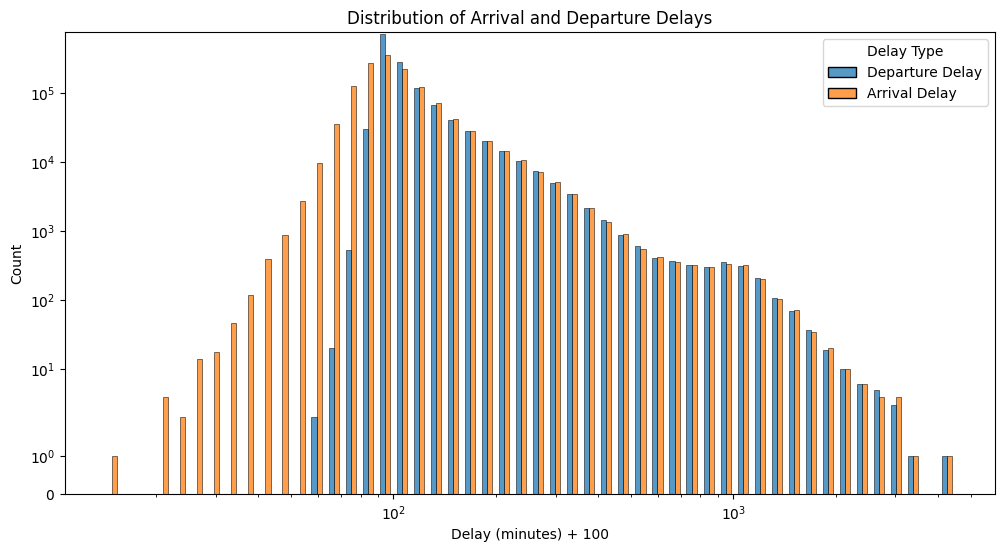

In [105]:
# Make a long-form dataframe separating departure and arrival delays
df_long_delays = df.melt(value_vars=['Departure Delay', 'Arrival Delay'], id_vars=['Airline'], 
                      var_name='Delay Type', value_name='Delay Time')

# Increase all delay values by 100 to avoid negative values for log transform
df_long_delays['Delay Time'] = df_long_delays['Delay Time'] + 100

# Plot the distribution of delays
_, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_long_delays, bins=50, shrink=0.6, hue='Delay Type', x='Delay Time', log_scale=True, multiple='dodge', ax=ax)
ax.set_xlabel('Delay (minutes) + 100')
ax.set_title('Distribution of Arrival and Departure Delays')
ax.set_yscale('symlog')

Overall, we can see that the vast majority of flights are either not delayed or only slightly delayed, with a few flights arriving early and being delayed significantly. As expected, the distribution of delays is strongly skewed to the right, with the maximum arrival delay being 4405 minutes, equal to over 73 hours! This makes sense because planes can only fly so fast, limiting how early they can be. However, countless issues can cause delays. Also, there is a large spike in departure delays at about 0 minutes with few planes departing early, which makes sense because passengers expect to be able to board the plane as long as they show up on time. However, there are many more early arrivals which may be because of favorable winds or light traffic at airports.

Next, we look at departure and arrival delays for flights that depart from a few different cities with a lot of data.

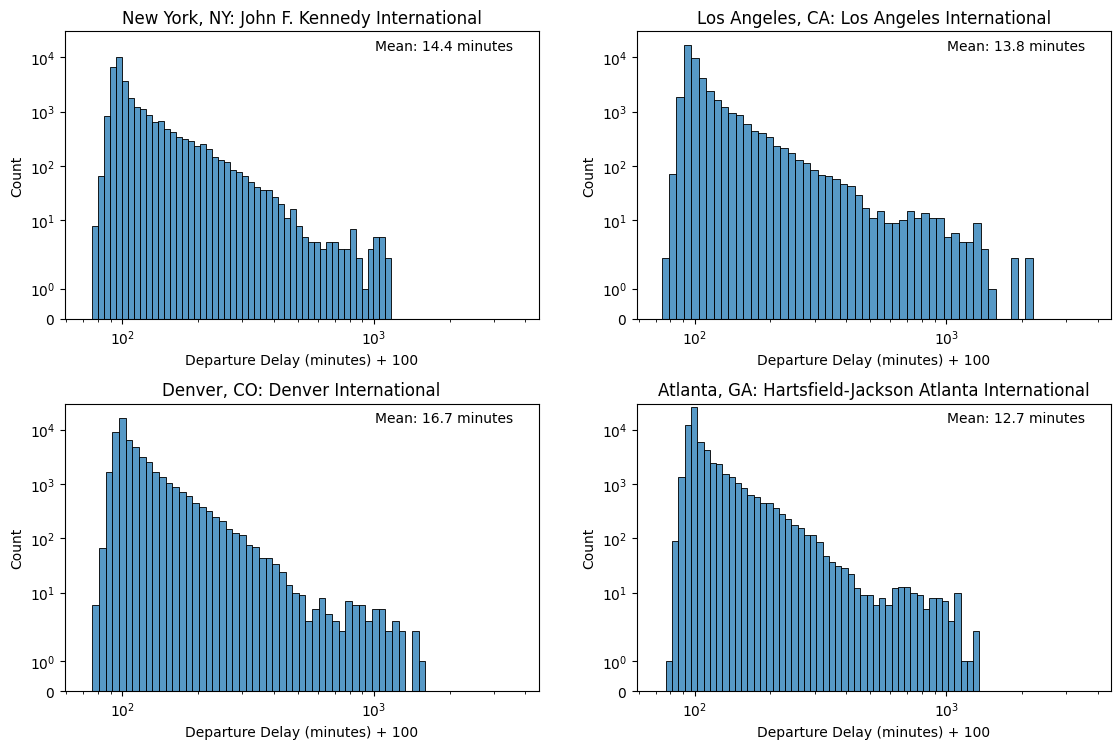

In [106]:
rows, cols = 2, 2
fig, ax = plt.subplots(rows, cols, figsize=(12, 8))
fig.tight_layout(pad=4.0)
selected_airports = ['New York, NY: John F. Kennedy International', 'Los Angeles, CA: Los Angeles International', 
            'Denver, CO: Denver International', 'Atlanta, GA: Hartsfield-Jackson Atlanta International']

for i in range(rows):
    for j in range(cols):
        city = selected_airports[i * cols + j]
        sns.histplot(df[df['Origin Airport'] == city]['Departure Delay'] + 100, bins=50, log_scale=True, ax=ax[i, j])
        ax[i, j].set_title(city)
        ax[i, j].set_xlabel('Departure Delay (minutes) + 100')
        ax[i, j].set_xlim(min(df['Departure Delay']) + 100, max(df['Departure Delay']) + 100)
        ax[i, j].set_ylim(0, 30000)
        ax[i, j].set_yscale('symlog')
        plt.text(0.8, 0.95, 'Mean: ' + str(round(df[df['Origin Airport'] == city]['Departure Delay'].mean(), 1)) + ' minutes',
                        horizontalalignment='center', verticalalignment='center', transform=ax[i, j].transAxes)
        
# Reduce all delay values by 100 to revert back to original values
df_long_delays['Delay Time'] = df_long_delays['Delay Time'] - 100

Overall, the departure delay distributions are very similar between these airports, and no airport has a significantly higher mean delay than any of the others. Furthermore, there seems to be little pattern in which airports see the most delays. We expected that airports that face severe winter weather would have more delays, but it's unclear whether this is the case because while Denver has the highest mean delay, New York's is on par with the other airports that don't experience winter weather.

Now, we look at arrival delays for each arrival airport in the same way. Again, we add 100 to each delay to prevent negative values, allowing a log transform to be used.

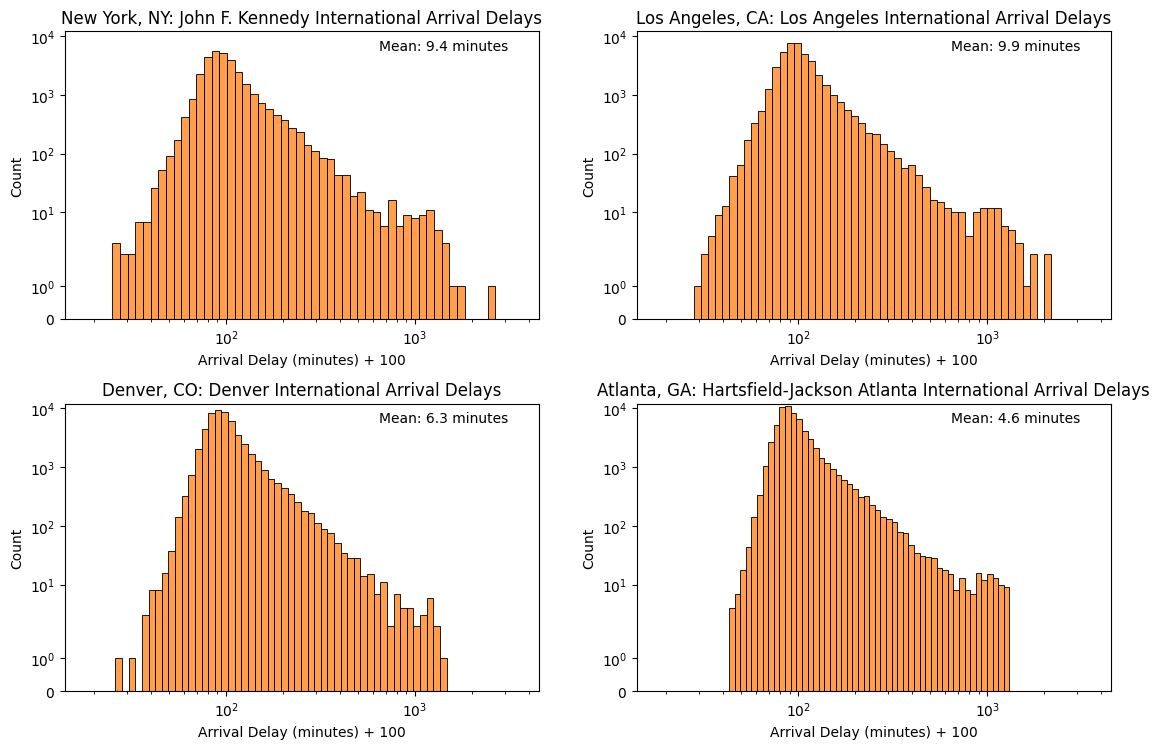

In [107]:
rows, cols = 2, 2
fig, ax = plt.subplots(rows, cols, figsize=(12, 8))
fig.tight_layout(pad=4.0)

for i in range(rows):
    for j in range(cols):
        city = selected_airports[i * cols + j]
        sns.histplot(df[df['Destination Airport'] == city]['Arrival Delay'] + 100, bins=50, log_scale=True, ax=ax[i, j], color='tab:orange')
        ax[i, j].set_title(city + ' Arrival Delays')
        ax[i, j].set_xlabel('Arrival Delay (minutes) + 100')
        ax[i, j].set_xlim(min(df['Arrival Delay']) + 100, max(df['Arrival Delay']) + 100)
        ax[i, j].set_ylim(0, 12000)
        ax[i, j].set_yscale('symlog')
        plt.text(0.8, 0.95, 'Mean: ' + str(round(df[df['Destination Airport'] == city]['Arrival Delay'].mean(), 1)) + ' minutes',
                        horizontalalignment='center', verticalalignment='center', transform=ax[i, j].transAxes)

The distributions look very similar to the departure delay distributions, and the means are slightly lower. This makes sense because planes can only fly so fast and have limits to how much time they can spend in the air, so a significant correlation between departure and arrival delays is expected. Also, the mean arrival delays, like the departure delays, are very similar between the airports, and the distributions are very similar between them. However, Denver, which had a slightly higher mean departure delay than the other airports, doesn't have the highest mean arrival delay.

Now, we look at scheduled and actual flight lengths.

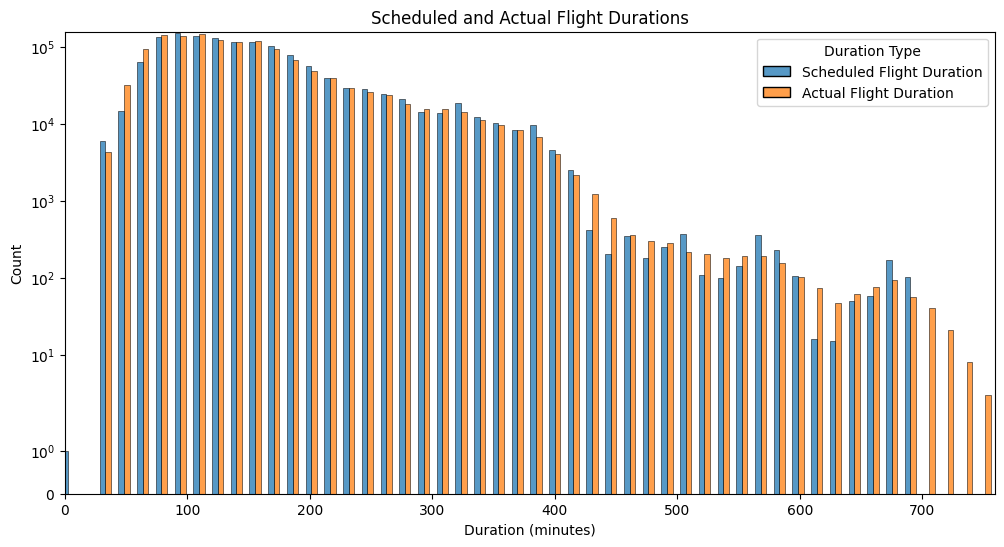

In [108]:
# Make a long-form dataframe separating scheduled and actual flight lengths
df_long_durations = df.melt(value_vars=['Scheduled Flight Duration', 'Actual Flight Duration'], 
                      var_name='Duration Type', value_name='Duration')

# Plot the distribution of flight durations
_, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_long_durations, bins=50, shrink=0.6, hue='Duration Type', x='Duration', multiple='dodge', ax=ax)
ax.set_xlabel('Duration (minutes)')
ax.set_xlim(0, df['Actual Flight Duration'].max())
ax.set_title('Scheduled and Actual Flight Durations')
ax.set_yscale('symlog')

As expected, the distributions of scheduled and actual flight lengths are very similar. This makes sense because as with the distributions of departure and arrival times, planes can only fly so fast and have limits to how much time they can spend in the air. In addition, most flights are fairly short, with the majority of flights being under 3 hours (180 minutes) long. However, there is a long right tail, which contains transcontinental flights and flights to Hawaii.

Now, we look at the average departure and arrival delay for each airline.

Text(0, 0.5, 'Airline')

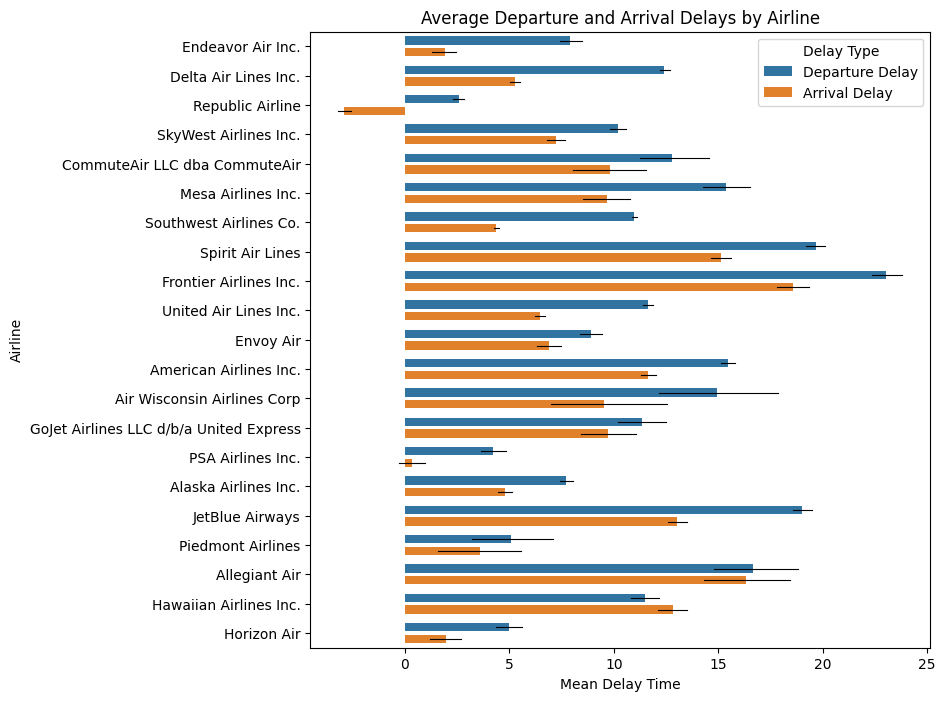

In [109]:
_, ax = plt.subplots(figsize=(8, 8))
sns.barplot(data=df_long_delays, x='Delay Time', y='Airline', hue='Delay Type', gap=0.3, ax=ax, err_kws={'linewidth': 0.8, 'color': 'black'})
ax.set_title('Average Departure and Arrival Delays by Airline')
ax.set_xlabel('Mean Delay Time')
ax.set_ylabel('Airline')

The same trend is seen in departure and arrival delays as before, with departure delays being slightly longer than arrival delays on average. In addition, there is some variation between the average delays of different airlines, but no single airline has a significantly higher mean delay than any of the others.

Now, we look at the average departure and arrival delays over time.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


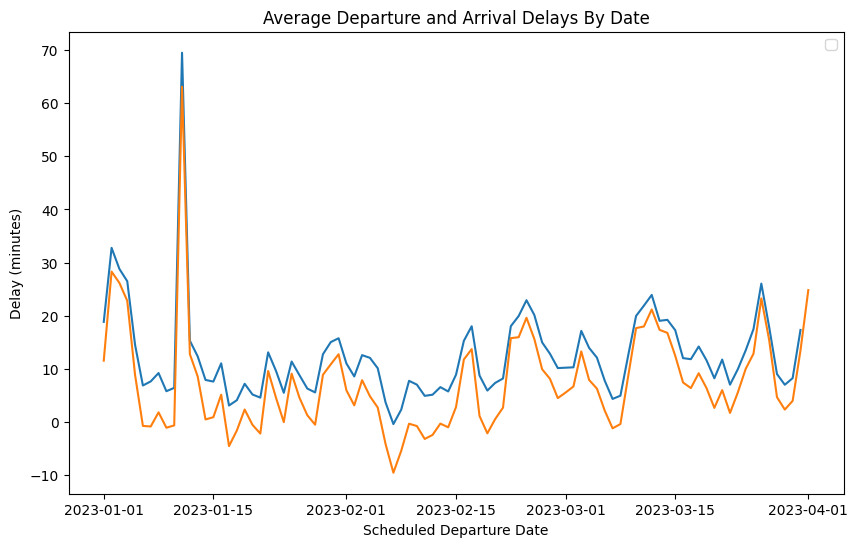

In [110]:
# Extract the date from the scheduled departure and arrival times
df['Scheduled Departure Date'] = df['Scheduled Departure Time'].dt.date
df['Scheduled Arrival Date'] = df['Scheduled Arrival Time'].dt.date

# Plot the delays
_, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x='Scheduled Departure Date', y='Departure Delay', ax=ax, errorbar=None)
sns.lineplot(data=df, x='Scheduled Arrival Date', y='Arrival Delay', ax=ax, errorbar=None)
ax.set_title('Average Departure and Arrival Delays By Date')
ax.set_ylabel('Delay (minutes)')
ax.legend()

# Remove the date columns
df = df.drop(columns=['Scheduled Departure Date', 'Scheduled Arrival Date'])

Again, there is a strong correlation between arrival and departure delays with arrival delays being slightly lower. Also, there was a large spike in typical delays around January 11th. This could be due to a winter storm or some other event that affected many flights.

Now, we look directly at the correlation between arrival and departure delays for each individual flight. Only a small subset (every 10000th) of flights in the dataset are plotted in order to make the graph readable, and 100 is added to each delay to allow a log scale to be used.

Text(0.5, 1.0, 'Departure Delay vs Arrival Delay')

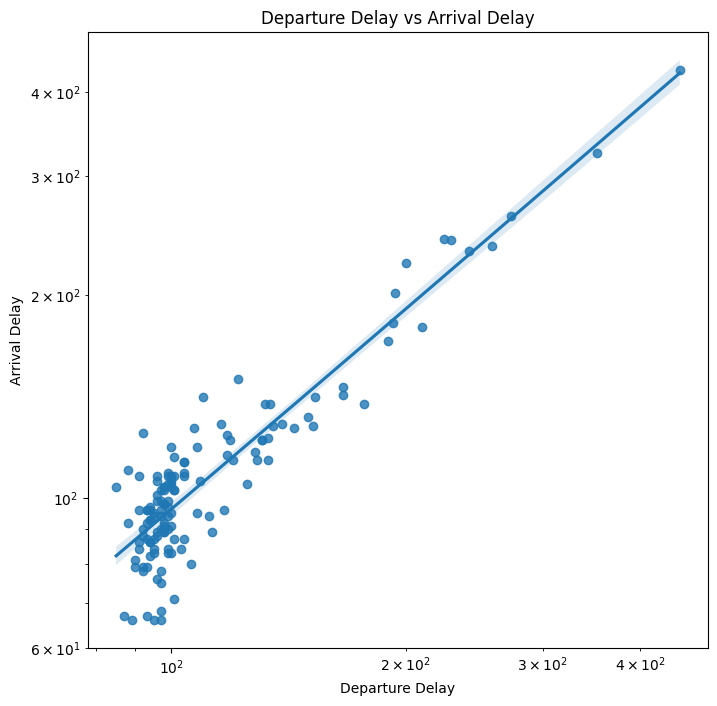

In [111]:
# Only plot every 10000th flight to make the graph more readable and transform the data to avoid negative values
transform = df.iloc[1::10000][['Departure Delay', 'Arrival Delay']].apply(lambda x: x + 100)

# Plot the data and regression line
_, ax = plt.subplots(figsize=(8, 8))
sns.regplot(data=transform, x='Departure Delay', y='Arrival Delay', ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Departure Delay vs Arrival Delay')

As the previous graphs have shown, it is clear that there is a strong correlation between departure and arrival delays.

## Prices

We look at the average price for a flight on each airline by adding up the total price paid by all passengers on the airline in the dataset adn dividing by the number of passengers.

Text(0.5, 0, 'Average Price')

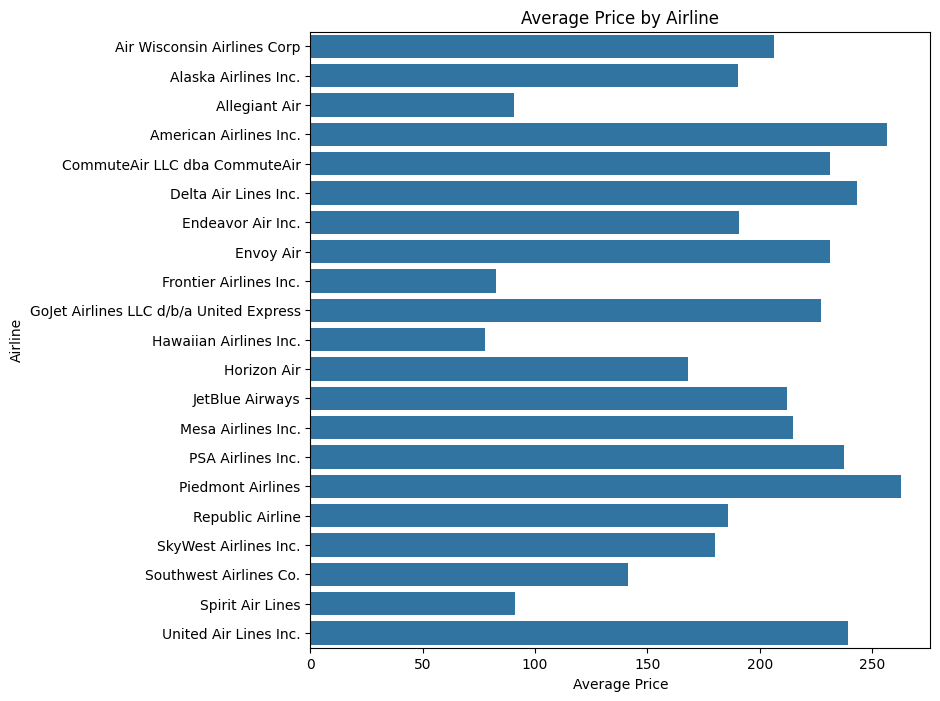

In [112]:
# Maybe change to boxplot

_, ax = plt.subplots(figsize=(8, 8))
df['Total Price'] = df['Average Price'] * df['Passengers']
averages = df.groupby('Airline')['Total Price'].sum() / df.groupby('Airline')['Passengers'].sum()
sns.barplot(x=averages.values, y=averages.index, ax=ax)
ax.set_title('Average Price by Airline')
ax.set_xlabel('Average Price')

There is significant variation in average ticket prices between the airlines. Budget airlines like Southwest and Spirit have lower typical fares, while major airlines like Delta and United have higher typical fares, as expected.

We look at the prices of flights departing from and arriving to select airports. Since there are too many airports to look at all of them, we look at every 10th airport in the dataset.

Text(0, 0.5, 'Airport')

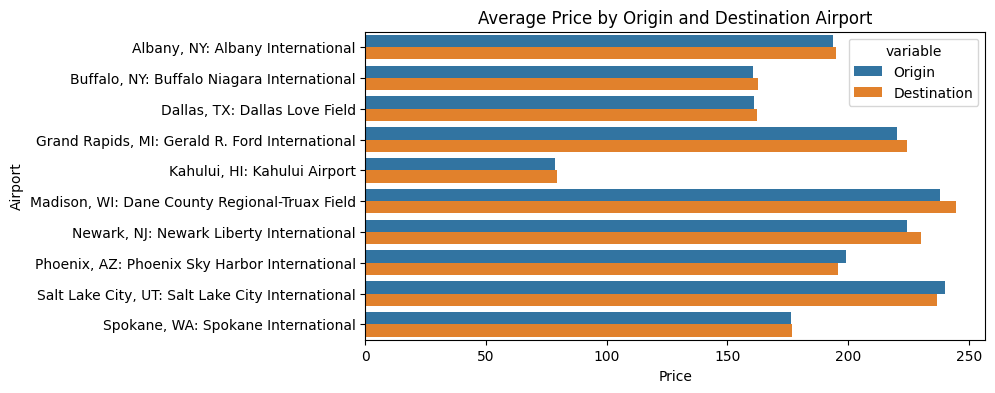

In [113]:
# Calculate the average prices
df['Total Price'] = df['Average Price'] * df['Passengers']
averages_origin = df.groupby('Origin Airport')['Total Price'].sum() / df.groupby('Origin Airport')['Passengers'].sum()
averages_destination = df.groupby('Destination Airport')['Total Price'].sum() / df.groupby('Destination Airport')['Passengers'].sum()
averages = pd.DataFrame({'Origin': averages_origin, 'Destination': averages_destination})[::10]
df = df.drop('Total Price', axis=1)
averages = averages.reset_index().melt(id_vars='index', value_vars=['Origin', 'Destination'])

# Plot the graph 
_, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x='value', y='index', hue='variable', data=averages, ax=ax)
ax.set_title('Average Price by Origin and Destination Airport')
ax.set_xlabel('Price')
ax.set_ylabel('Airport')

There is significant variation in the prices of flights departing from different airports. This could be explained by several factors, including some airports being more popular during the months of January-March or some airports being hubs for budget or traditional airlines. Also, as expected, the prices for flights departing from and arriving at the same airport are very similar, with similar variation between airports as well.

## Airports

We look at the geographic distribution of the 100 most common airports in the delay data.

In [114]:
# Create a map centered on the US (generated by GitHub Copilot with prompt "Create a map centered on the US")
us_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Add markers for each airport
for i in range(100):
    folium.Marker([latitudes[i], longitudes[i]], popup=weather_airports[i]).add_to(us_map)

us_map

The selected airports are well-distributed across the populated areas of the US, including Alaska, Hawaii, and Puerto Rico. Thus, in the selected airports, there is not a significant bias towards any region of the US.

## Weather

We plot the temperatures over the 3-month period for the airports we previously looked at the delay distributions for.

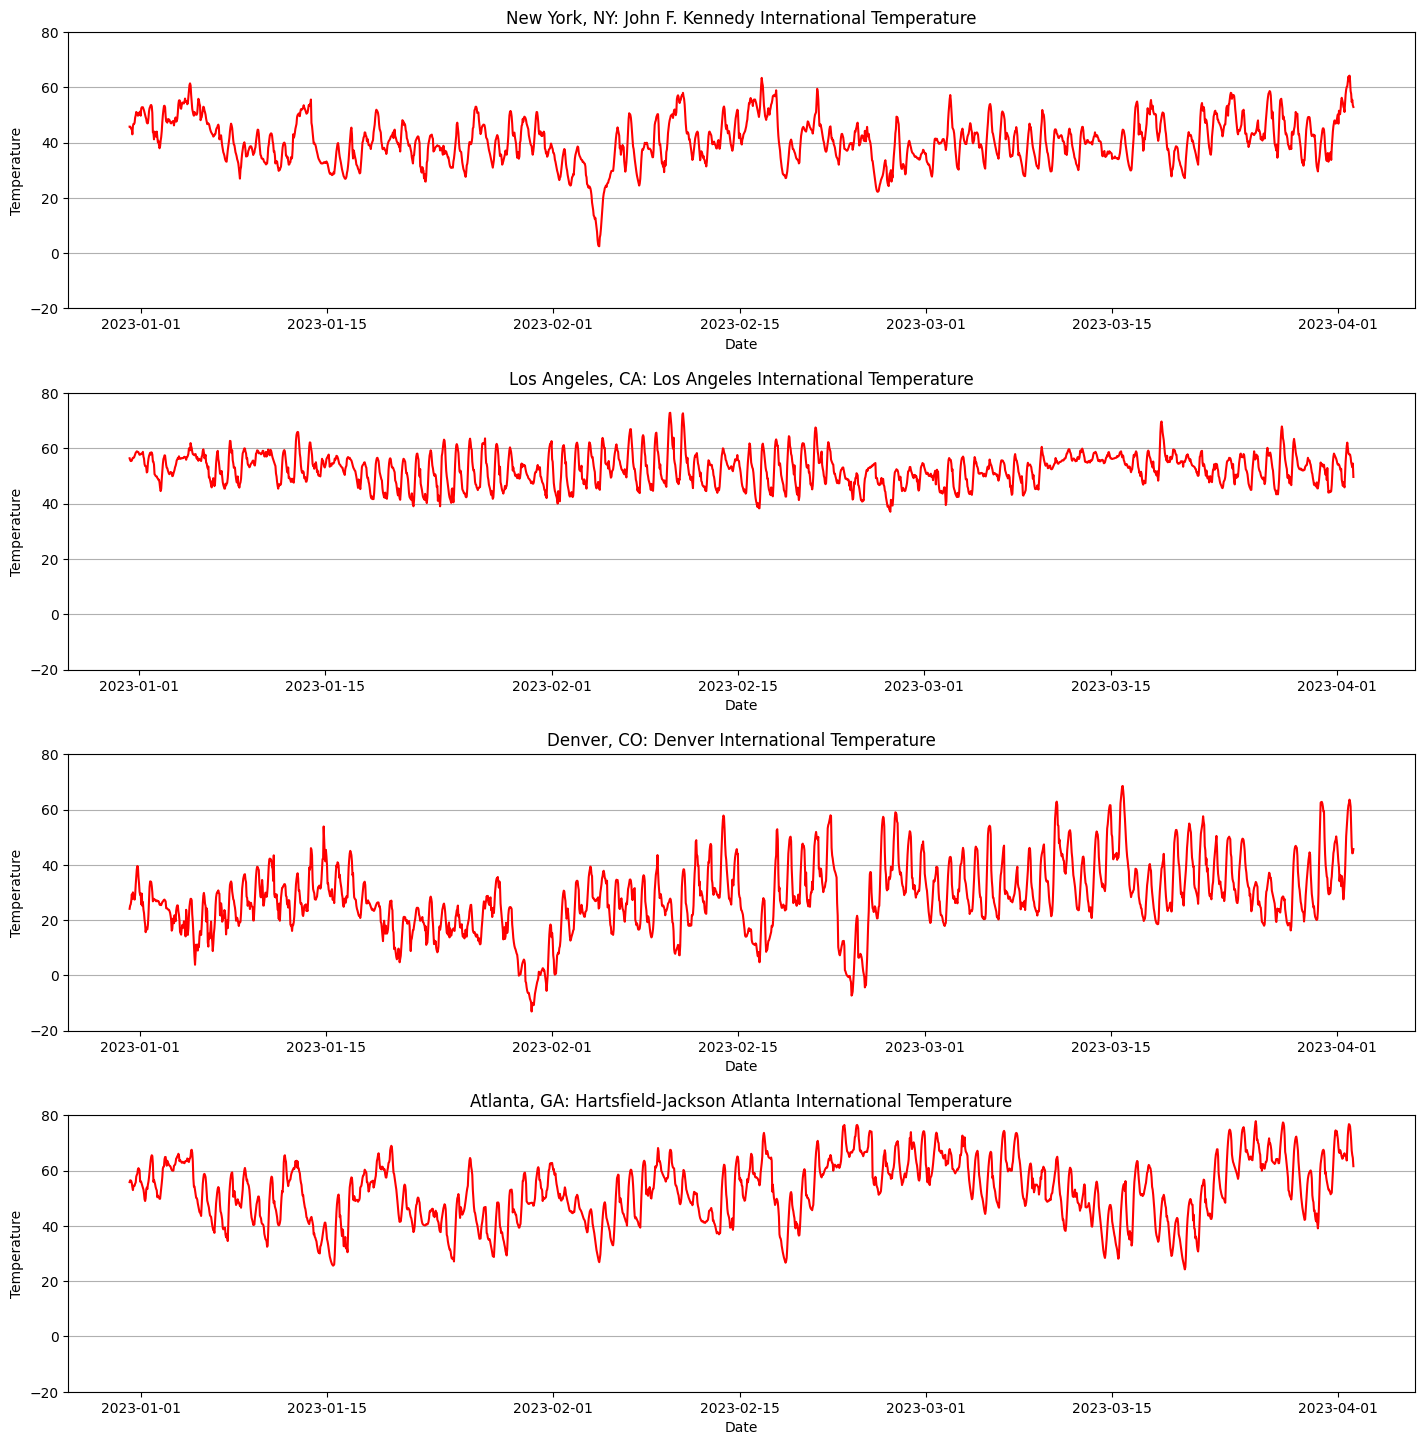

In [115]:
rows = 4
fig, ax = plt.subplots(4, 1, figsize=(15, 15))
fig.tight_layout(pad=4.0)

for i in range(rows):
    airport = selected_airports[i]
    subset = weather[weather['Airport'] == airport]
    sns.lineplot(data=subset, x='Time', y='Temperature', ax=ax[i], color='red')

    ax[i].grid(axis='y')
    ax[i].set_xlabel('Date')
    ax[i].set_ylim(-20, 80)
    ax[i].set_title(airport + ' Temperature')

As expected, all of these airports have different temperature patterns. Denver, New York, and to a lesser degree Atlanta have widely varying temperatures, while Los Angeles is consistently mild. In general, all of the airports except for Los Angeles have a slight upward trend in temperatures over time, which makes sense as the data ranges from January to March. Also, all of the data shows a clear day/night cycle in temperature.

Now, we plot the daily precipitation for those airports.

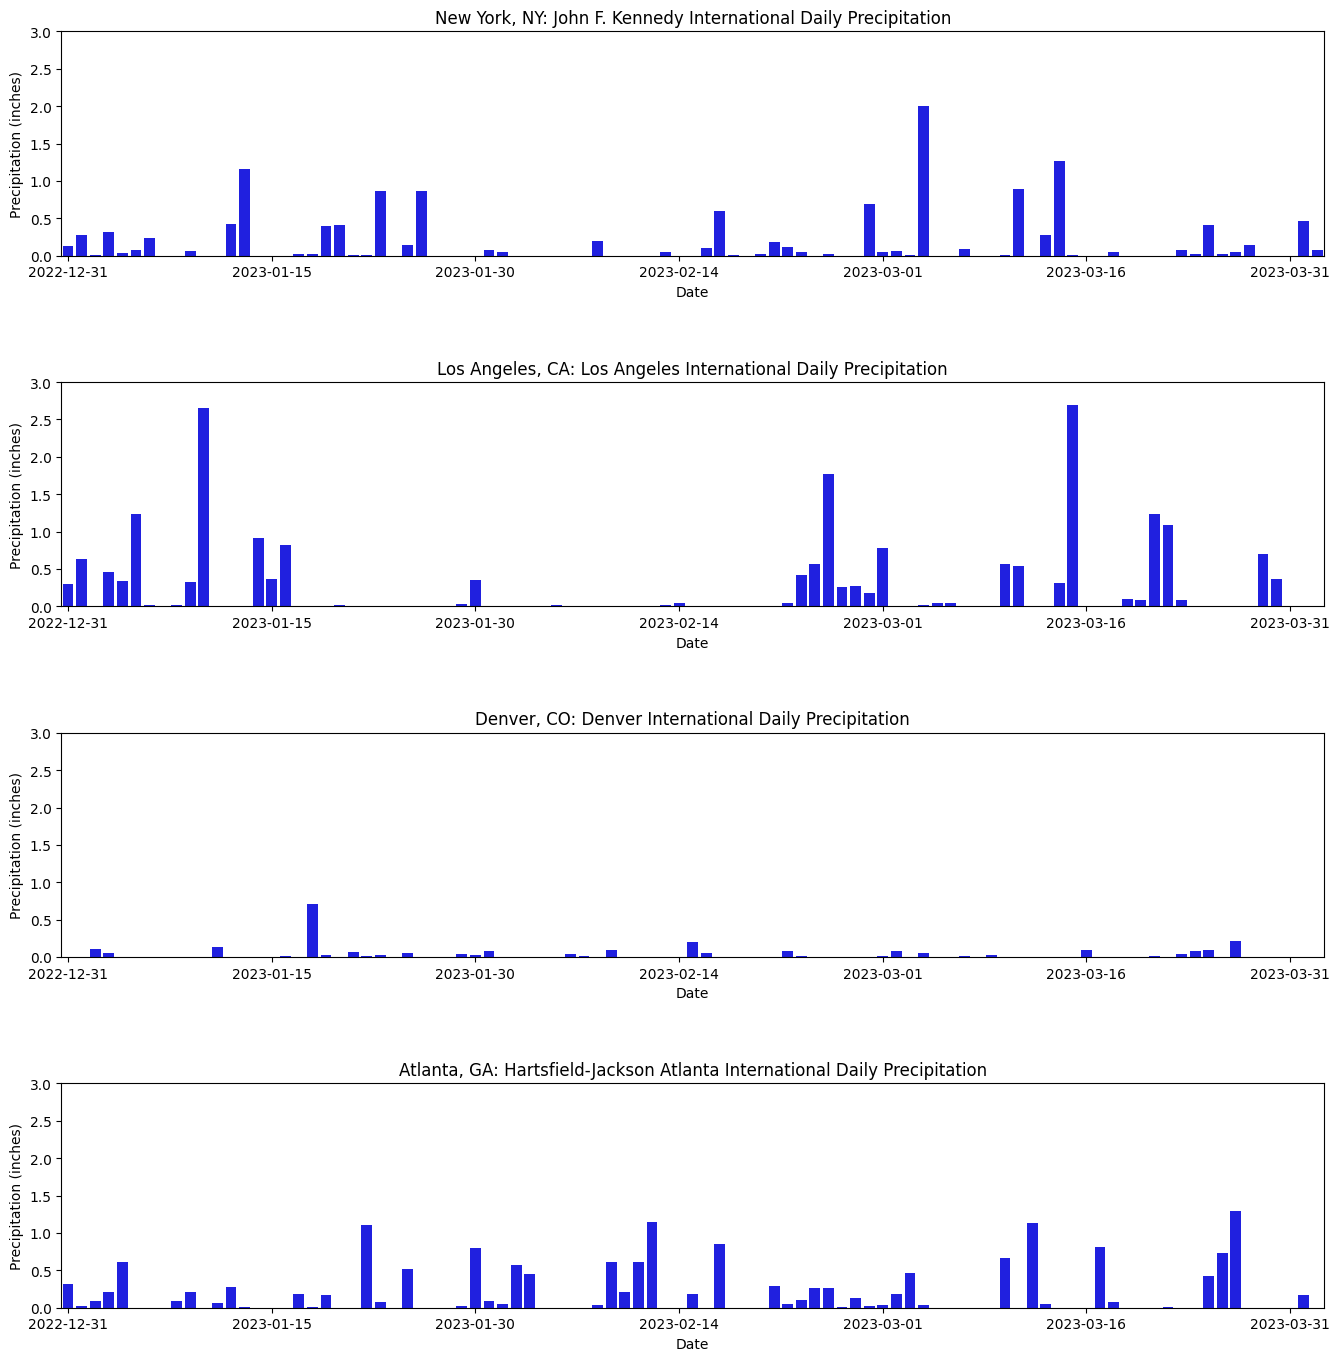

In [116]:
rows = 4
fig, ax = plt.subplots(4, 1, figsize=(15, 15))
fig.tight_layout(pad=7.0)

for i in range(rows):
    airport = selected_airports[i]
    subset = weather[weather['Airport'] == airport]
    daily_precip = subset.resample('D', on='Time')['Precipitation'].sum()
    sns.barplot(x=daily_precip.index, y=daily_precip.values, ax=ax[i], color='blue')

    ax[i].set_xlabel('Date')
    ax[i].set_title(airport + ' Daily Precipitation')
    ax[i].set_xticklabels(ax[i].get_xticklabels()[::15])
    ax[i].set_xticks(ax[i].get_xticks()[::15])
    ax[i].set_ylim(0, 3)
    ax[i].set_ylabel('Precipitation (inches)')

The precipitation patterns vary significantly between airports. In general, there are multiple days in a row of precipitation and then several dry days. Over this time period, Los Angeles had several days with heavy precipitation but also had many dry days, while Atlanta and New York City had more consistent but less heavy precipitation. Denver had the least precipitation, with only a handful of days of light precipitation.


# Inferential Analysis

After the EDA, now it's time to carry out the inferential analysis required to answer our question of interest.

For this part, we will use the `df` dataset, which combined all the necessary variables for our analysis.

In [117]:
df.head()

,Origin Airport,Destination Airport,Airline,Scheduled Departure Time,Scheduled Arrival Time,Departure Delay,Arrival Delay,Scheduled Flight Duration,Actual Flight Duration,Passengers,...,Departure Wind Gusts,Arrival Temperature,Arrival Humidity,Arrival Precipitation,Arrival Rain,Arrival Snow,Arrival Pressure,Arrival Low Cloud Cover,Arrival Wind Speed,Arrival Wind Gusts
0,"Albany, NY: Albany International","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 05:45:00,2023-01-01 07:55:00,307.0,288.0,130.0,111.0,107,...,14.093101,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
1,"Cincinnati, OH: Cincinnati/Northern Kentucky I...","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 06:10:00,2023-01-01 07:35:00,-7.0,-33.0,85.0,59.0,221,...,9.842800,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
2,"Norfolk, VA: Norfolk International","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 05:30:00,2023-01-01 07:35:00,6.0,-7.0,125.0,112.0,232,...,19.461899,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
3,"Portland, ME: Portland International Jetport","Detroit, MI: Detroit Metro Wayne County",Delta Air Lines Inc.,2023-01-01 05:15:00,2023-01-01 07:48:00,47.0,19.0,153.0,125.0,140,...,11.632400,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711
4,"Rochester, NY: Frederick Douglass Grtr Rochest...","Detroit, MI: Detroit Metro Wayne County",Endeavor Air Inc.,2023-01-01 06:15:00,2023-01-01 07:53:00,-5.0,-21.0,98.0,82.0,213,...,20.132999,26.878099,96.708008,0.0,0.0,0.0,1014.599976,0.0,5.524982,6.711


Let's make a heatmap to look at the correlation between the variables in ``df``.

<Axes: >

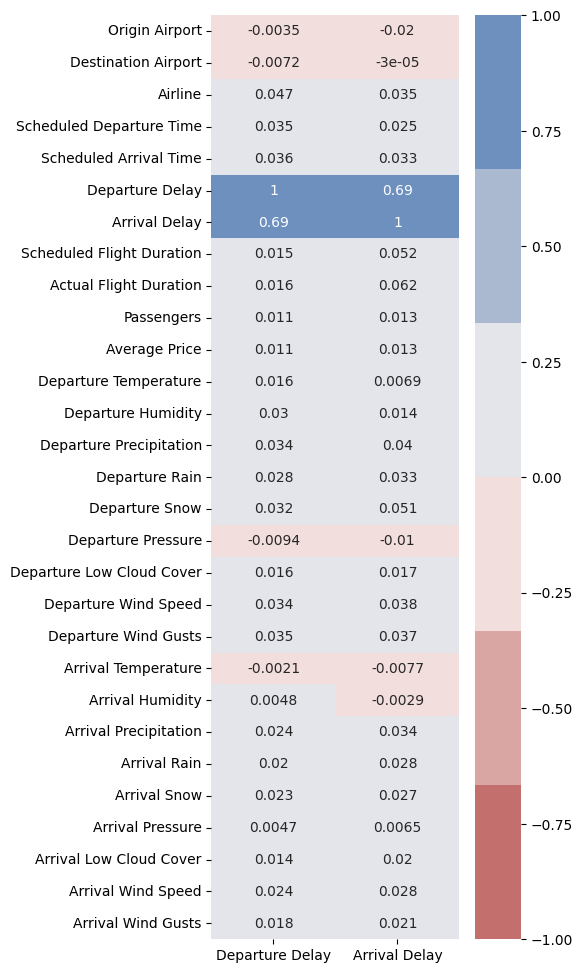

In [118]:
# https://stackoverflow.com/questions/48035381/correlation-among-multiple-categorical-variables
_, ax = plt.subplots(figsize=(4, 12))
cmap = sns.color_palette('vlag_r')
sns.heatmap(df.apply(lambda x : pd.factorize(x)[0]).corr(method='pearson', min_periods=1)[['Departure Delay', 'Arrival Delay']], 
            ax=ax, annot=True, cmap=cmap, vmin=-1, vmax=1)

As we can see, most of the variables have a weak correlation with both departure and arrival delays. However, as we saw in the EDA, there is a strong correlation between departure and arrival delays.

Let's take a look at the top 10 origin airports that have most departure delays.

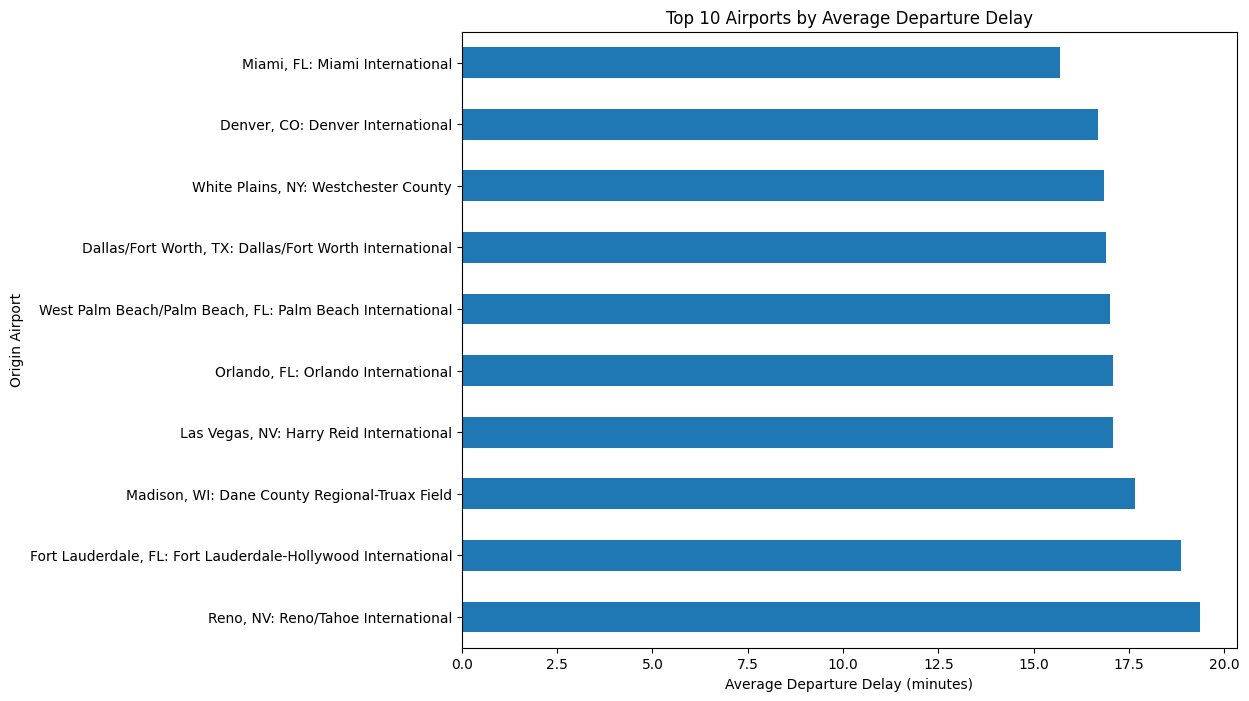

In [119]:
df[['Departure Delay', 'Origin Airport']]

# Group by 'Airports' and calculate aggregate functions
airport_delays = df.groupby('Origin Airport')['Departure Delay'].agg(['mean', 'median', 'count', 'sum'])

# Sort the airports by mean delay to see which have the highest average delays
sorted_airports = airport_delays.sort_values('mean', ascending=False)

# Visualize the top N airports with the highest average delays
top_n = 10 
top_airports = sorted_airports.head(top_n)
top_airports['mean'].plot(kind='barh', figsize=(10, 8))
plt.xlabel('Average Departure Delay (minutes)')
plt.title(f'Top {top_n} Airports by Average Departure Delay')
plt.show()

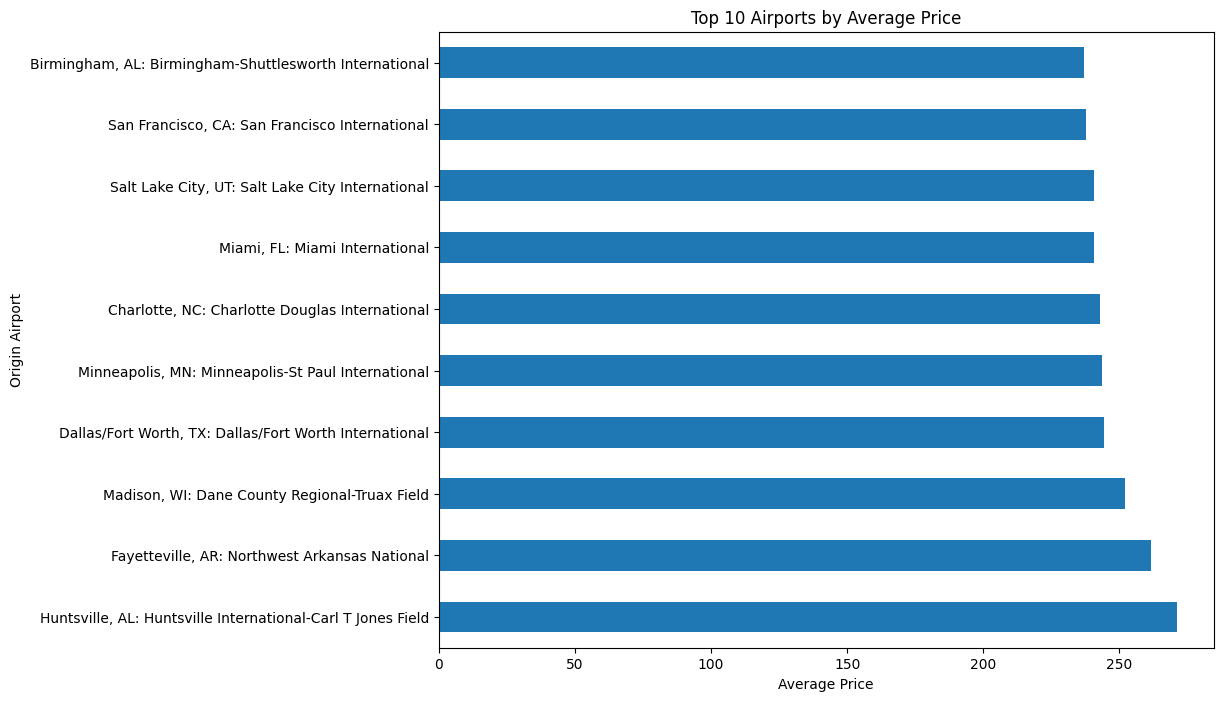

In [120]:
df[['Average Price', 'Origin Airport']]

# Group by 'Airports' and calculate aggregate functions
airport_delays = df.groupby('Origin Airport')['Average Price'].agg(['mean', 'median', 'count', 'sum'])

# Sort the airports by mean delay to see which have the highest average delays
sorted_airports = airport_delays.sort_values('mean', ascending=False)

# Visualize the top N airports with the highest average delays
top_n = 10 
top_airports = sorted_airports.head(top_n)
top_airports['mean'].plot(kind='barh', figsize=(10, 8))
plt.xlabel('Average Price')
plt.title(f'Top {top_n} Airports by Average Price')
plt.show()

As you can see, the average delay and average price vary by airport, which indicates prices do not necessarily correlate with delays.

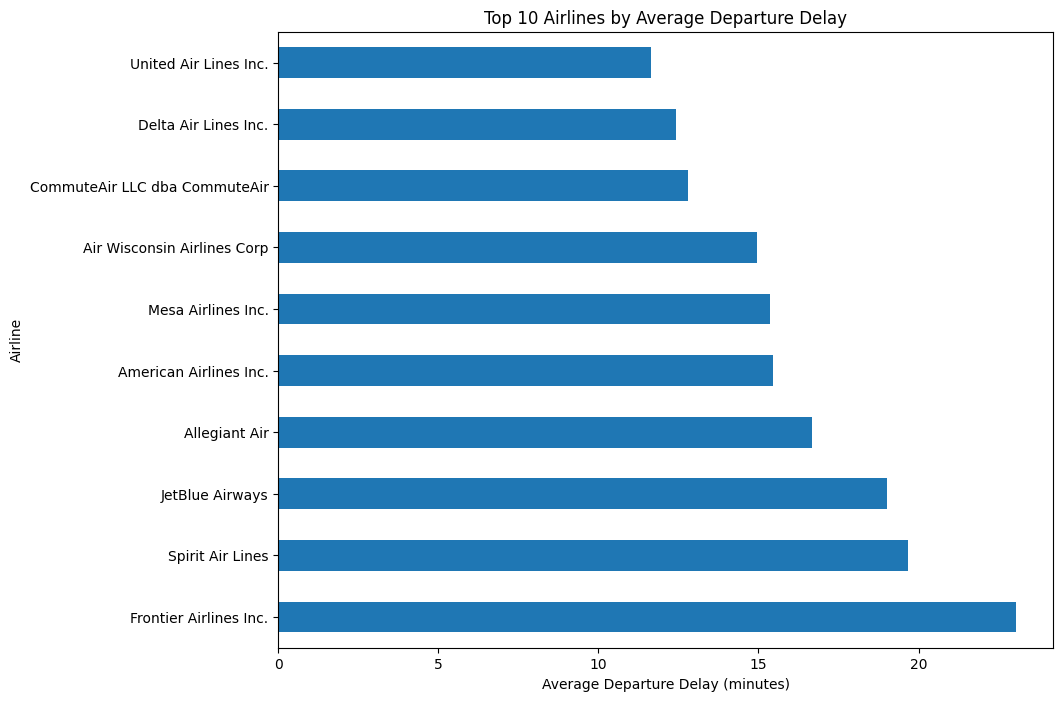

In [121]:
df[['Departure Delay', 'Airline']]

# Group by 'Airports' and calculate aggregate functions
airport_delays = df.groupby('Airline')['Departure Delay'].agg(['mean', 'median', 'count', 'sum'])

# Sort the airports by mean delay to see which have the highest average delays
sorted_airports = airport_delays.sort_values('mean', ascending=False)

# Visualize the top N airports with the highest average delays
top_n = 10 
top_airports = sorted_airports.head(top_n)
top_airports['mean'].plot(kind='barh', figsize=(10, 8))
plt.xlabel('Average Departure Delay (minutes)')
plt.title(f'Top {top_n} Airlines by Average Departure Delay')
plt.show()

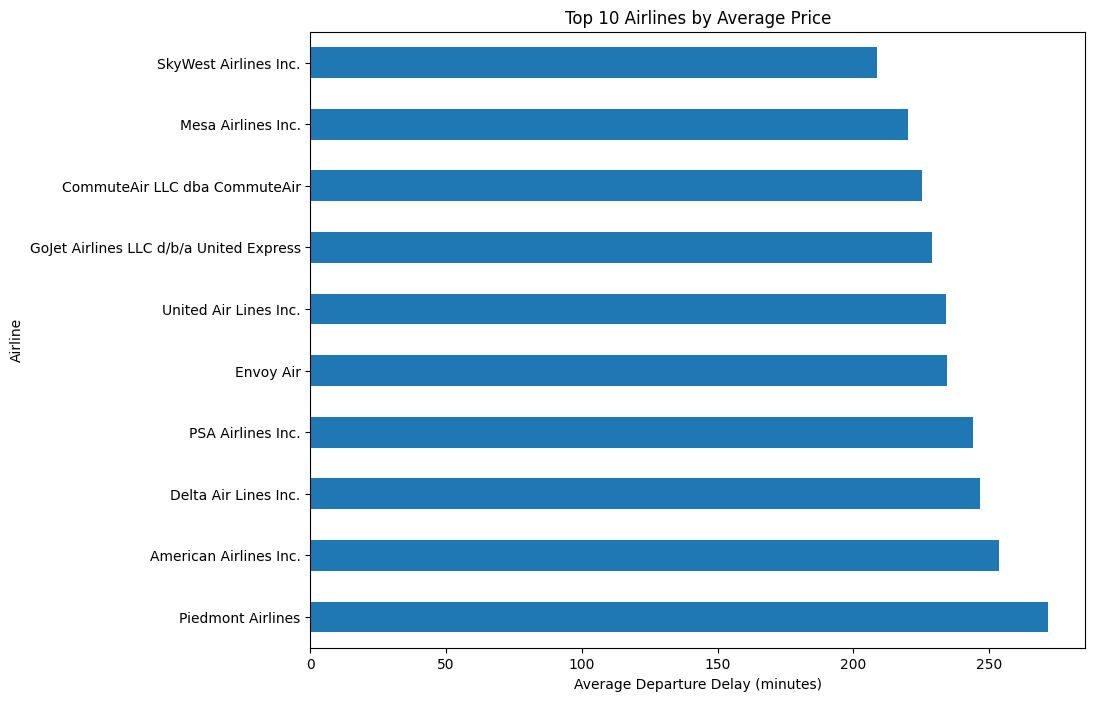

In [122]:
df[['Average Price', 'Airline']]

# Group by 'Airports' and calculate aggregate functions
airport_delays = df.groupby('Airline')['Average Price'].agg(['mean', 'median', 'count', 'sum'])

# Sort the airports by mean delay to see which have the highest average delays
sorted_airports = airport_delays.sort_values('mean', ascending=False)

# Visualize the top N airports with the highest average delays
top_n = 10 
top_airports = sorted_airports.head(top_n)
top_airports['mean'].plot(kind='barh', figsize=(10, 8))
plt.xlabel('Average Departure Delay (minutes)')
plt.title(f'Top {top_n} Airlines by Average Price')
plt.show()

The airlines are not consistent with the relationship between price and delays as well, which once again indicates little relationship.

To get a better understanding of what is related, let's plot each instance of price, weather (in this case precipitation), and delays on our scatterplots.

Text(0.5, 1.0, 'Average Price vs Departure Delay')

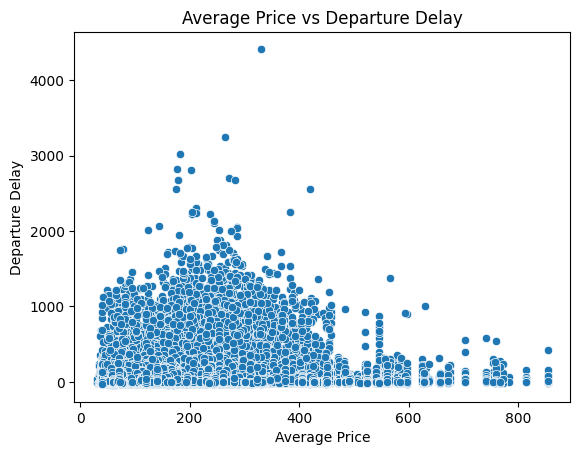

In [123]:
sns.scatterplot(data = df, x = 'Average Price', y = 'Departure Delay')
plt.title('Average Price vs Departure Delay')

Text(0.5, 1.0, 'Departure Precipitation vs Departure Delay')

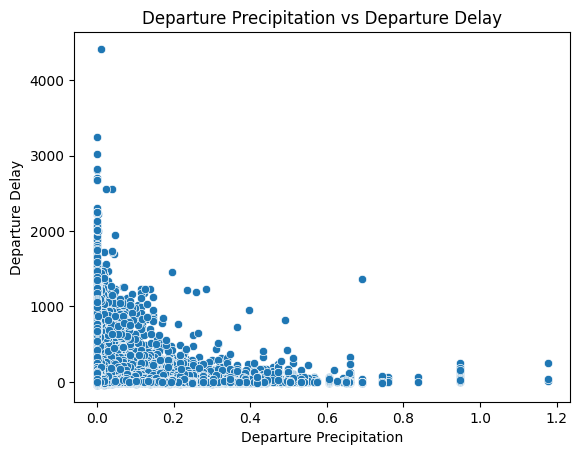

In [124]:
sns.scatterplot(data = df, x = 'Departure Precipitation', y = 'Departure Delay')
plt.title('Departure Precipitation vs Departure Delay')

Text(0.5, 1.0, 'Average Price vs Departure Precipitation')

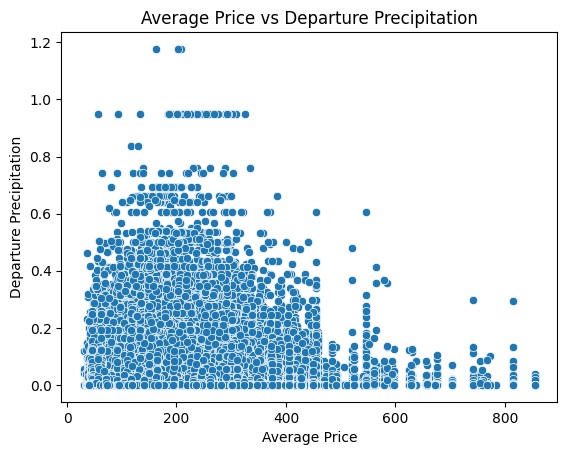

In [125]:
sns.scatterplot(data = df, x = 'Average Price', y = 'Departure Precipitation')
plt.title('Average Price vs Departure Precipitation')

Although there's no clear correlation, there is a slight suggestion that higher prices do not necessarily lead to higher delays, as we can see that even for higher-priced flights, delays can still be on the lower side. Similarly, it does not seem weather has a significant relationship either, but there is more of a relationship present between price and weather data. 

However, to be more precise, let's create a linear model to see the coefficients.

In [126]:
X = df[['Average Price']]  # Predictor variable
y = df['Departure Delay']  # Response variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict the Departure Delay for the test data
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Output the model coefficients and evaluation metrics
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept: {intercept}")
print(f"Coefficient for Average Price: {coefficient}")
print(f"R^2 Score: {r2}")
print(f"Mean Squared Error: {mse}")

Intercept: 12.56228588588873
Coefficient for Average Price: -0.0010771176288361507
R^2 Score: 1.1711057487984178e-05
Mean Squared Error: 2791.5842947673004


In [127]:
X = df[['Departure Precipitation']]  # Predictor variable
y = df['Departure Delay']  # Response variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict the Departure Delay for the test data
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Output the model coefficients and evaluation metrics
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept: {intercept}")
print(f"Coefficient for Average Price: {coefficient}")
print(f"R^2 Score: {r2}")
print(f"Mean Squared Error: {mse}")

Intercept: 11.954404830932617
Coefficient for Average Price: 75.78056335449219
R^2 Score: 0.0015828834356366173
Mean Squared Error: 2787.198183266085


In [128]:
X = df[['Average Price']]  # Predictor variable
y = df['Departure Precipitation']  # Response variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict the Departure Delay for the test data
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Output the model coefficients and evaluation metrics
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept: {intercept}")
print(f"Coefficient for Average Price: {coefficient}")
print(f"R^2 Score: {r2}")
print(f"Mean Squared Error: {mse}")

Intercept: 0.004762880759736812
Coefficient for Average Price: 2.02808352688297e-06
R^2 Score: 6.048160738580943e-05
Mean Squared Error: 0.000623784604664997


The negative coefficient indicates an inverse relationship between price and delay, but the relationship is very weak.
Given the R² score is near zero, we can say that there is no meaningful linear relationship between 'Average Price' and 'Departure Delay' based on the data you've analyzed. We also looked at the different weather variables and none of them had a strong correlation with 'Deparutre Delay' either. 
The high MSE for the relationship price and weather have with delays indicates poor model performance, meaning the actual departure delays vary significantly from what the model predicts. However, the model is much more accurate with the correlation between price and weather.

# Ethics & Privacy

In conducting our data analysis project on flight delays, we recognize the paramount importance of upholding strict ethical standards and maintaining privacy. We are committed to ensuring that our study respects the principles of fairness, accountability, and transparency.

### Fairness
We examined the datasets for any biases, particularly those that could unjustly disadvantage any individual or group. While our data concerns operational aspects of flight performance, weather information acquired from a general perspective, prices that are set clear, and does not include personally identifiable information, we will try our best to ensure that the interpretation of data does not lead to discriminatory practices against any demographic group. Any findings related to price disparities, service quality, or delays will be contextualized within the complexity of airline operations and presented with caution to avoid misrepresentation.

### Accountability
Our team is accountable for the accurate and respectful use of data. We plan to implement rigorous data handling procedures, quality checks, and peer reviews to prevent errors and misinterpretations. If our analyses reveal patterns that could indicate systemic biases within the industry or specific airlines, we will report these responsibly, ensuring that we do not make unfounded accusations and that our findings are backed by robust statistical evidence.

### Transparency
Transparency is key to ethical data science. We provide clear documentation of our data sources, methodologies, and analytical processes. In addition, we will be open about the limitations of our study and the potential for error, ensuring that readers and stakeholders can make informed judgments about the reliability and applicability of our results.

### Privacy
Although the datasets we plan to use do not contain direct personal information, we will treat all information with the utmost respect for privacy. In line with data minimization principles, we will only use data that is necessary for our research objectives. We will also comply with all applicable privacy laws and guidelines, including those related to the aggregation and anonymization of data, to ensure that privacy is protected even in indirect ways.



# Discussion and Conclusion

Our analysis delved into various facets of flight operations, focusing on flight delays, pricing dynamics, and their interplay with geographic and weather factors. Examining departure and arrival delays revealed a skewed distribution, with the majority of flights experiencing minor or no delays. However, severe delays, often influenced by factors like adverse weather conditions, were evident across departure and arrival segments. Notably, departure and arrival delays exhibited a strong correlation, indicating common underlying causes affecting both phases of the flight. While departure delays varied among airports, no distinct pattern emerged regarding airports' susceptibility to delays, suggesting a multifaceted nature of delay-inducing factors beyond geographical location.

In assessing the relationship between flight prices and delays, our analysis found no clear correlation. Despite expectations that higher-priced flights might offer better service or operational efficiency, ticket prices did not consistently predict departure delays. Similarly, departure precipitation, often a harbinger of weather-related disruptions, showed a weak association with flight prices, highlighting the complexity of pricing strategies in the aviation industry. Geographic distribution analysis of airports with high delay rates underscored the absence of a discernible pattern, further emphasizing the multifactorial nature of flight delays.

Our inferential analysis, employing linear regression models, corroborated the lack of a significant relationship between flight prices and departure delays. While a weak inverse relationship was observed, indicating that higher-priced flights tended to experience marginally fewer delays, the models exhibited poor predictive performance. Low R² scores and high mean squared errors suggested that flight prices alone were insufficient predictors of departure delays. Similarly, departure precipitation failed to serve as a reliable predictor of delay occurrence, further highlighting the limitations of linear modeling in capturing the intricate dynamics of flight operations.

Moving forward, our findings underscore the need for a comprehensive approach to address flight delays and optimize pricing strategies in the aviation industry. Airlines and airport authorities should prioritize the identification and mitigation of factors contributing to delays, such as operational inefficiencies and weather-related disruptions. Pricing strategies must evolve to consider a broader range of factors beyond flight delays, including demand elasticity and competitive dynamics, to maximize revenue and enhance customer satisfaction. Future research endeavors should explore additional variables and interactions to gain deeper insights into the underlying drivers of flight delays and pricing dynamics, potentially leveraging more advanced modeling techniques and incorporating external data sources for a holistic understanding of aviation operations.

In conclusion, while our analysis sheds light on various aspects of flight operations, it also underscores the complexity and multifactorial nature of flight delays and pricing dynamics in the aviation industry. By addressing these challenges through targeted interventions and informed decision-making, stakeholders can strive towards enhancing operational efficiency, improving service quality, and delivering enhanced value to passengers and stakeholders alike.

# Team Contributions

| Person | Contributions |
| --- | --- |
| Stevie | analysis, wrote hypothesis, assisted with EDA |
| Zak | getting data, data cleaning, merging datasets, EDA graphs |
| Jessica | cleaning data and presentation slides |
| Andrew | conclusion, fixing graphs + labels, editing final video |
| Arrie (Yuxuan) | Project management & Organization, Analysis, Background + Ethics, Video |